# Transformer 基础

Transformer 是 2017 年论文 "Attention Is All You Need" 提出的架构，彻底改变了 NLP 领域，后来也扩展到视觉（ViT）和多模态（CLIP）。

### 为什么需要 Transformer？

之前的序列模型（RNN、LSTM）有两个致命问题：

1. **串行计算**：必须一个 token 一个 token 地处理，无法并行，训练慢
2. **长距离依赖**：信息在序列中传递时会衰减，很难记住很久以前的内容

Transformer 用 **Self-Attention（自注意力）** 机制解决了这两个问题：
- 每个 token 可以同时看到所有其他 token，天然支持并行
- 不管距离多远，信息直接传递，不存在衰减

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"设备: {device}")

设备: cuda


## 1. Self-Attention（自注意力）

### 核心思想

对于序列中的每个 token，计算它和其他所有 token 的「相关性」，然后根据相关性做加权求和。

比如句子「猫 坐 在 垫子 上」，处理「坐」这个 token 时：
- 和「猫」很相关（谁在坐？）
- 和「垫子」相关（坐在哪？）
- 和「上」不太相关

### Q、K、V

Self-Attention 把每个 token 变成三个向量：

- **Q（Query，查询）**：「我在找什么信息？」
- **K（Key，键）**：「我有什么信息可以提供？」
- **V（Value，值）**：「我的实际内容是什么？」

注意力计算过程：
```
1. Q 和 K 做点积 → 得到注意力分数（相关性）
2. 除以 sqrt(d_k) → 稳定数值
3. Softmax → 归一化为概率
4. 乘以 V → 加权求和得到输出
```

公式：`Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) × V`

In [2]:
# Self-Attention 手动实现

def self_attention(x, d_k):
    """
    x: 输入 (batch, seq_len, d_model)
    d_k: K 向量的维度
    """
    # 用线性层生成 Q, K, V
    W_q = nn.Linear(x.size(-1), d_k).to(x.device)
    W_k = nn.Linear(x.size(-1), d_k).to(x.device)
    W_v = nn.Linear(x.size(-1), d_k).to(x.device)

    Q = W_q(x)  # (batch, seq_len, d_k)
    K = W_k(x)  # (batch, seq_len, d_k)
    V = W_v(x)  # (batch, seq_len, d_k)

    # 步骤1: Q × K^T → 注意力分数
    scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch, seq_len, seq_len)

    # 步骤2: 除以 sqrt(d_k) 稳定数值
    scores = scores / math.sqrt(d_k)

    # 步骤3: Softmax 归一化
    attn_weights = F.softmax(scores, dim=-1)  # (batch, seq_len, seq_len)

    # 步骤4: 乘以 V
    output = torch.matmul(attn_weights, V)  # (batch, seq_len, d_k)

    return output, attn_weights

# 测试
x = torch.randn(1, 4, 8)  # batch=1, 4个token, 每个8维
out, weights = self_attention(x, d_k=8)

print(f"输入: {x.shape}")
print(f"输出: {out.shape}")
print(f"注意力权重: {weights.shape}")
print(f"\n注意力权重（每个token对其他token的关注度）:")
print(weights[0].detach().numpy().round(3))

输入: torch.Size([1, 4, 8])
输出: torch.Size([1, 4, 8])
注意力权重: torch.Size([1, 4, 4])

注意力权重（每个token对其他token的关注度）:
[[0.132 0.282 0.343 0.243]
 [0.18  0.304 0.338 0.178]
 [0.339 0.238 0.183 0.24 ]
 [0.323 0.301 0.15  0.227]]


### 为什么除以 sqrt(d_k)？

Q 和 K 的点积结果的方差会随维度 d_k 增大而增大。如果值太大，Softmax 会变得非常尖锐（接近 one-hot），梯度会消失。

除以 sqrt(d_k) 让方差回到 1，Softmax 的输出更平滑，训练更稳定。

In [3]:
# sqrt(d_k) 的作用演示
d_k = 64
q = torch.randn(1, 10, d_k)
k = torch.randn(1, 10, d_k)

# 不除 sqrt(d_k)
scores_raw = torch.matmul(q, k.transpose(-2, -1))
print(f"不缩放: 均值={scores_raw.mean():.2f}, 方差={scores_raw.var():.2f}")
print(f"Softmax 后: {F.softmax(scores_raw, dim=-1)[0][0].detach().numpy().round(3)}")

# 除以 sqrt(d_k)
scores_scaled = scores_raw / math.sqrt(d_k)
print(f"\n缩放后: 均值={scores_scaled.mean():.2f}, 方差={scores_scaled.var():.2f}")
print(f"Softmax 后: {F.softmax(scores_scaled, dim=-1)[0][0].detach().numpy().round(3)}")

不缩放: 均值=-0.05, 方差=56.29
Softmax 后: [0.311 0.    0.047 0.642 0.    0.    0.    0.    0.    0.   ]

缩放后: 均值=-0.01, 方差=0.88
Softmax 后: [0.204 0.038 0.161 0.223 0.082 0.083 0.089 0.05  0.039 0.029]


## 2. Multi-Head Attention（多头注意力）

### 为什么需要多个头？

一个注意力头只能学一种「关注模式」。但语言中有很多种关系：
- 语法关系（主语-谓语）
- 语义关系（同义词）
- 位置关系（相邻的词）

多头注意力让模型同时学习多种关注模式。

### 做法

```
1. 把 Q, K, V 分成多个头（比如 8 个）
2. 每个头独立做 Self-Attention
3. 把所有头的输出拼接起来
4. 用一个线性层合并
```

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # 输出投影

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        # 生成 Q, K, V
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)

        # 拆分成多个头: (batch, seq_len, d_model) → (batch, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # 每个头独立做注意力
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)  # (batch, num_heads, seq_len, d_k)

        # 拼接所有头: (batch, num_heads, seq_len, d_k) → (batch, seq_len, d_model)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        # 输出投影
        output = self.W_o(attn_output)
        return output, attn_weights

# 测试
mha = MultiHeadAttention(d_model=64, num_heads=8).to(device)
x = torch.randn(2, 10, 64).to(device)  # batch=2, 10个token, 64维
out, weights = mha(x)

print(f"输入: {x.shape}")
print(f"输出: {out.shape}")
print(f"注意力权重: {weights.shape}  (batch, heads, seq, seq)")
print(f"每个头的维度: {64 // 8} = d_model / num_heads")

输入: torch.Size([2, 10, 64])
输出: torch.Size([2, 10, 64])
注意力权重: torch.Size([2, 8, 10, 10])  (batch, heads, seq, seq)
每个头的维度: 8 = d_model / num_heads


## 3. Positional Encoding（位置编码）

### 问题：Attention 没有位置信息

Self-Attention 是「集合操作」——打乱 token 的顺序，结果不变。但语言是有顺序的：「猫吃鱼」和「鱼吃猫」意思完全不同。

### 解决：给每个位置加一个编码

用正弦/余弦函数生成位置编码，加到 token 的表示上：

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

为什么用正弦余弦？因为它们能表达相对位置关系——PE(pos+k) 可以用 PE(pos) 的线性变换表示。

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # 预计算位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度用 sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度用 cos

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)  # 不需要梯度

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]

# 测试
pe = PositionalEncoding(d_model=64)
x = torch.zeros(1, 10, 64)  # 全零输入
out = pe(x)

print(f"输入（全零）: {x.shape}")
print(f"加位置编码后: {out.shape}")
print(f"\n位置编码不为零: {out.abs().sum() > 0}")
print(f"说明位置信息被加进去了")

输入（全零）: torch.Size([1, 10, 64])
加位置编码后: torch.Size([1, 10, 64])

位置编码不为零: True
说明位置信息被加进去了


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found 

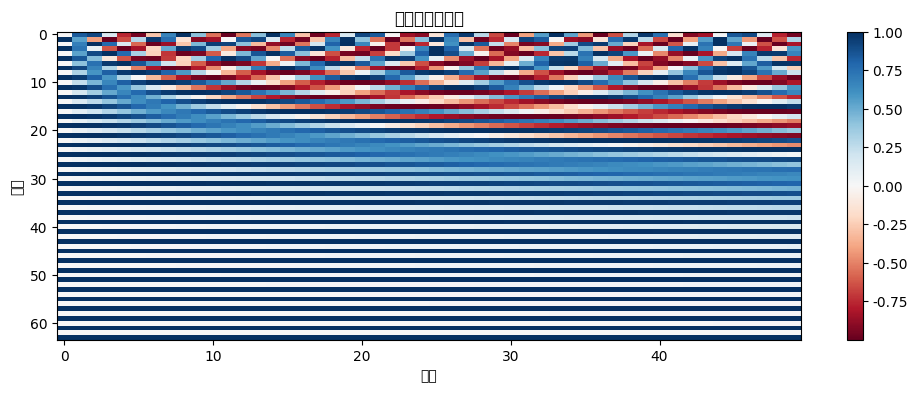

In [8]:
# 可视化位置编码
import matplotlib.pyplot as plt


pe = PositionalEncoding(d_model=64)
pe_vals = pe.pe[0, :50, :].numpy()  # 前50个位置

plt.figure(figsize=(12, 4))
plt.imshow(pe_vals.T, aspect='auto', cmap='RdBu')
plt.xlabel('位置')
plt.ylabel('维度')
plt.title('位置编码可视化')
plt.colorbar()
plt.show()

## 4. Layer Normalization

和 BatchNorm 不同，LayerNorm 是对**每个样本的特征维度**做标准化，不依赖 batch 内其他样本。

```
BatchNorm: 对一个 batch 内同一个通道的所有样本标准化
LayerNorm: 对单个样本的所有特征维度标准化
```

Transformer 用 LayerNorm 而不是 BatchNorm，因为序列长度不固定，BatchNorm 不太合适。

In [9]:
# BatchNorm vs LayerNorm
x = torch.randn(4, 10, 64)  # batch=4, seq_len=10, d_model=64

bn = nn.BatchNorm1d(64)  # 对特征维度做 BN
ln = nn.LayerNorm(64)    # 对特征维度做 LN

# BatchNorm 需要把 seq 维度合并
x_bn = x.view(-1, 64)  # (40, 64)
out_bn = bn(x_bn).view(4, 10, 64)

# LayerNorm 直接对最后一维
out_ln = ln(x)

print(f"输入: {x.shape}")
print(f"BatchNorm 输出: {out_bn.shape}")
print(f"LayerNorm 输出: {out_ln.shape}")
print(f"\nLayerNorm 每个样本独立标准化，不依赖 batch 内其他样本")

输入: torch.Size([4, 10, 64])
BatchNorm 输出: torch.Size([4, 10, 64])
LayerNorm 输出: torch.Size([4, 10, 64])

LayerNorm 每个样本独立标准化，不依赖 batch 内其他样本


## 5. Transformer Encoder Block

一个 Encoder Block 的结构：

```
x → Multi-Head Attention → Add & LayerNorm → Feed Forward → Add & LayerNorm → 输出
↓                              ↑                   ↓                          ↑
└──────── skip connection ─────┘   └── skip connection ──┘
```

注意：Transformer 也有 skip connection（和 ResNet 一样），加上 LayerNorm，这就是 "Add & Norm"。

In [10]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        # Multi-Head Attention
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        # Feed Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Attention + Residual + LayerNorm
        attn_out, _ = self.attention(x)
        x = self.norm1(x + self.dropout1(attn_out))  # skip connection + norm

        # FFN + Residual + LayerNorm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))    # skip connection + norm

        return x

# 测试
encoder_block = TransformerEncoderBlock(d_model=64, num_heads=8, d_ff=256).to(device)
x = torch.randn(2, 10, 64).to(device)
out = encoder_block(x)

print(f"输入: {x.shape}")
print(f"输出: {out.shape}")
print(f"参数量: {sum(p.numel() for p in encoder_block.parameters()):,}")

输入: torch.Size([2, 10, 64])
输出: torch.Size([2, 10, 64])
参数量: 49,984


## 6. 完整 Transformer Encoder

把上面的组件组合起来：

```
输入 → Token Embedding + Positional Encoding → N × Encoder Block → 输出
```

In [11]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len=512, dropout=0.1):
        super().__init__()
        # Embedding
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        # N 个 Encoder Block
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        # x: (batch, seq_len) — token 的索引
        x = self.embedding(x)          # (batch, seq_len, d_model)
        x = self.pos_encoding(x)       # 加位置编码
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x)

        return x  # (batch, seq_len, d_model)

# 测试
model = TransformerEncoder(
    vocab_size=1000,    # 词表大小
    d_model=64,         # 每个 token 的维度
    num_heads=8,        # 注意力头数
    d_ff=256,           # FFN 中间层维度
    num_layers=4,       # Encoder 层数
).to(device)

x = torch.randint(0, 1000, (2, 20)).to(device)  # batch=2, 20个token
out = model(x)

print(f"输入: {x.shape}  (batch, seq_len)")
print(f"输出: {out.shape}  (batch, seq_len, d_model)")
print(f"\n参数量: {sum(p.numel() for p in model.parameters()):,}")

输入: torch.Size([2, 20])  (batch, seq_len)
输出: torch.Size([2, 20, 64])  (batch, seq_len, d_model)

参数量: 263,936


## 总结

### Transformer 的核心组件

| 组件 | 作用 |
|------|------|
| Self-Attention | 让每个 token 看到所有其他 token |
| Multi-Head Attention | 同时学习多种关注模式 |
| Positional Encoding | 给序列注入位置信息 |
| LayerNorm | 稳定训练（比 BatchNorm 更适合序列） |
| Skip Connection | 梯度直达，和 ResNet 一样 |
| FFN | 每个位置独立做非线性变换 |

### 和 CNN 的对比

| | CNN | Transformer |
|---|-----|-------------|
| 感受野 | 逐层扩大 | 第一层就是全局 |
| 并行性 | 可并行 | 完全可并行 |
| 位置信息 | 天然有（卷积核有位置） | 需要额外加 |
| 归纳偏置 | 强（局部性、平移不变性） | 弱（从数据学习） |
| 数据需求 | 较少 | 需要大量数据 |

下一篇：用 Transformer 做实际任务（文本分类或序列建模）。